# 05 — Advanced Architectures: QCNN & Quantum GAN
### QML Curriculum · Companion Notebook to Module 11 — *Advanced QML Architectures (Part 1)*

**Part of:** [Schrödinger's Cats — Quantum Machine Learning Platform](https://tanjinadnanabir.github.io/WISER-Education-Challenge/)

Notebooks 03–04 covered the two "core" QML patterns: trainable circuits and quantum kernels. This notebook builds two more advanced, specialized architectures on top of that same foundation:

- A **Quantum Convolutional Neural Network (QCNN)** — local, weight-shared "convolution" + "pooling" layers, echoing the classical CNN pattern, built entirely from the gates in Module 5
- A **Quantum GAN (QGAN)** — a generator circuit and a discriminator circuit, trained adversarially against each other

**By the end of this notebook you will be able to:**
- Build a QCNN with alternating **convolution** and **pooling** layers that shrink the active qubit count
- Train a QCNN classifier on structured synthetic data
- Build a minimal **quantum generator + quantum discriminator** GAN pair
- Understand why adversarial training is harder to stabilize than the supervised training from Notebook 03

**Prerequisites:** Notebooks 01–04, Module 11 (conceptual).

> ⚠️ These are genuinely advanced, research-adjacent architectures. Expect the QGAN section in particular to behave less predictably than earlier notebooks — that unpredictability is itself an accurate, honest lesson about adversarial training, quantum or classical.


In [1]:
# Setup
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
print("Ready.")

Ready.


## Part A — Quantum Convolutional Neural Network (QCNN)

### 1. The QCNN Pattern: Convolve, Then Pool, Repeat

A classical CNN alternates convolution (a small filter, shared across the whole image) with pooling (shrinking the image). A QCNN does the same thing structurally:

- **Convolution layer:** a small trainable 2-qubit block applied to every *neighboring pair* of active qubits — the same weights reused across every pair, exactly like a shared classical filter.
- **Pooling layer:** each pair is reduced to a single "surviving" qubit, which receives a controlled rotation from its partner before that partner drops out of later layers.

Repeat this a few times and an 8-qubit input shrinks to 4, then 2, then 1 — and that last qubit is measured for the final classification.

In [2]:
n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)

def conv_pool_layer(weights, wires):
    # Apply one shared conv+pool block to every neighboring pair in `wires`,
    # halving the number of active wires. Uses 5 trainable weights per pair.
    idx = 0
    surviving_wires = []
    for i in range(0, len(wires), 2):
        w1, w2 = wires[i], wires[i + 1]
        # -- convolution: a small 2-qubit trainable block --
        qml.RY(weights[idx], wires=w1); idx += 1
        qml.RY(weights[idx], wires=w2); idx += 1
        qml.CNOT(wires=[w1, w2])
        qml.RY(weights[idx], wires=w1); idx += 1
        qml.RY(weights[idx], wires=w2); idx += 1
        # -- pooling: pass w2's information into w1, then drop w2 --
        qml.CRZ(weights[idx], wires=[w2, w1]); idx += 1
        surviving_wires.append(w1)
    return surviving_wires

print("One conv+pool layer uses 5 weights per pair of qubits.")
print("8 qubits -> 4 pairs -> 20 weights for layer 1.")

One conv+pool layer uses 5 weights per pair of qubits.
8 qubits -> 4 pairs -> 20 weights for layer 1.


In [3]:
@qml.qnode(dev)
def qcnn(x, w1, w2, w3):
    # encode: angle encoding, exactly like Notebook 02
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)

    wires = list(range(n_qubits))
    wires = conv_pool_layer(w1, wires)   # 8 -> 4
    wires = conv_pool_layer(w2, wires)   # 4 -> 2
    wires = conv_pool_layer(w3, wires)   # 2 -> 1
    return qml.expval(qml.PauliZ(wires[0]))

# quick structural check with random weights
w1 = pnp.random.uniform(0, 2 * np.pi, 20, requires_grad=True)
w2 = pnp.random.uniform(0, 2 * np.pi, 10, requires_grad=True)
w3 = pnp.random.uniform(0, 2 * np.pi, 5, requires_grad=True)
x_test = np.random.uniform(0, np.pi, 8)
print("QCNN output for one random sample:", qcnn(x_test, w1, w2, w3))

QCNN output for one random sample: 0.1463045207477544


### 2. A Synthetic "Local Pattern" Dataset

QCNNs are built to notice **local** structure — neighboring elements that agree or disagree — the same way a classical CNN filter notices local edges in an image. We'll build two classes of 8-element signal that differ exactly in that local structure:

- **Class −1 (smooth):** neighboring values are close together (like a smooth curve)
- **Class +1 (checkerboard):** neighboring values alternate sharply between high and low

This is a simplified stand-in for "smooth region vs. edge" patterns in real image patches — small enough to train in seconds, structured enough for the convolution layers to have something local to detect.

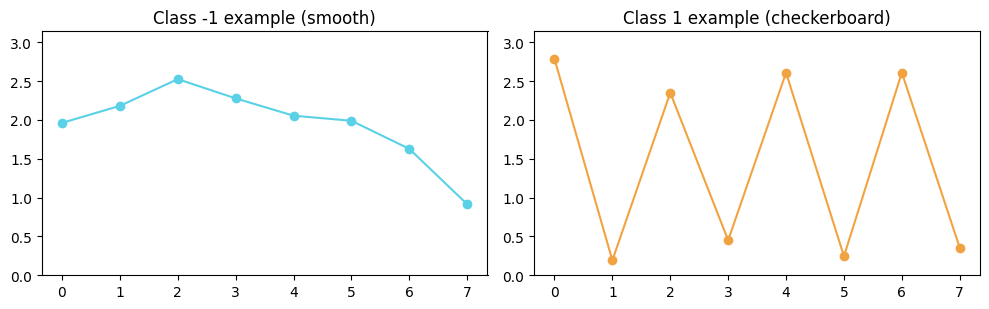

Train/test shapes: (32, 8) (16, 8)


In [4]:
def generate_dataset(n_samples):
    X, y = [], []
    t = np.linspace(0, np.pi, 8)
    for _ in range(n_samples):
        if np.random.rand() < 0.5:
            base = 1.5 + 1.0 * np.sin(t + np.random.uniform(0, 1))
            X.append(base + np.random.normal(0, 0.15, 8))
            y.append(-1)
        else:
            hi, lo = np.random.uniform(2.2, 2.8), np.random.uniform(0.2, 0.8)
            pattern = np.array([hi, lo] * 4)
            X.append(pattern + np.random.normal(0, 0.15, 8))
            y.append(1)
    return np.array(X), np.array(y)

X_train, y_train = generate_dataset(32)
X_test, y_test = generate_dataset(16)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for label, color, ax in [(-1, "#5ad1e6", axes[0]), (1, "#f2a341", axes[1])]:
    sample = X_train[y_train == label][0]
    ax.plot(sample, "o-", color=color)
    ax.set_title(f"Class {label} example ({'smooth' if label == -1 else 'checkerboard'})")
    ax.set_ylim(0, np.pi)
plt.tight_layout()
plt.show()

print("Train/test shapes:", X_train.shape, X_test.shape)

### 3. Training the QCNN

Same training pattern as Notebook 03's QNN: mean-squared error against ±1 labels, Adam optimizer, parameter-shift gradients under the hood.

In [5]:
def qcnn_cost(w1, w2, w3, X, y):
    preds = pnp.stack([qcnn(x, w1, w2, w3) for x in X])
    return pnp.mean((preds - y) ** 2)

def qcnn_accuracy(w1, w2, w3, X, y):
    preds = np.array([np.sign(qcnn(x, w1, w2, w3)) for x in X])
    return np.mean(preds == y)

opt = qml.AdamOptimizer(stepsize=0.2)
n_epochs = 20
history = []

for epoch in range(n_epochs):
    w1, w2, w3 = opt.step(lambda a, b, c: qcnn_cost(a, b, c, X_train, y_train), w1, w2, w3)
    if epoch % 4 == 0 or epoch == n_epochs - 1:
        c = qcnn_cost(w1, w2, w3, X_train, y_train)
        acc = qcnn_accuracy(w1, w2, w3, X_train, y_train)
        history.append((epoch, c))
        print(f"Epoch {epoch:2d} | cost = {c:.4f} | train accuracy = {acc*100:.1f}%")

test_acc = qcnn_accuracy(w1, w2, w3, X_test, y_test)
print(f"\nFinal test accuracy: {test_acc*100:.1f}%")

Epoch  0 | cost = 0.8779 | train accuracy = 93.8%


Epoch  4 | cost = 0.2582 | train accuracy = 100.0%


Epoch  8 | cost = 0.1714 | train accuracy = 100.0%


Epoch 12 | cost = 0.1310 | train accuracy = 100.0%


Epoch 16 | cost = 0.0922 | train accuracy = 100.0%


Epoch 19 | cost = 0.0663 | train accuracy = 100.0%

Final test accuracy: 100.0%


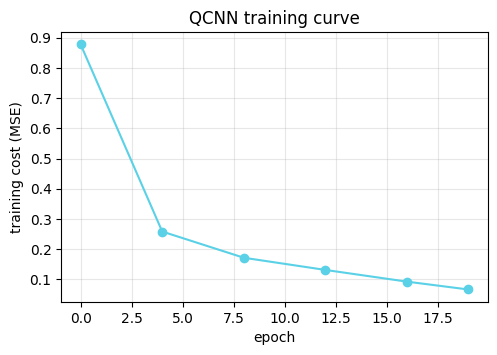

In [6]:
epochs_logged, costs_logged = zip(*history)
plt.figure(figsize=(5.5, 3.5))
plt.plot(epochs_logged, costs_logged, "o-", color="#5ad1e6")
plt.xlabel("epoch")
plt.ylabel("training cost (MSE)")
plt.title("QCNN training curve")
plt.grid(alpha=0.3)
plt.show()

### 🔧 Try it yourself
The dataset's two classes differ in *local, adjacent-pair* structure — exactly what convolution layers are built to notice. Write a new `generate_dataset`-style function where the two classes only differ in their **overall average value** (a *global*, not local, feature) and retrain. Does the same QCNN architecture still reach high accuracy as easily?

In [7]:
# YOUR CODE HERE -- e.g. class -1: mean ~1.0 + noise; class +1: mean ~2.0 + noise,
# with no particular pairwise/local structure otherwise.


## Part B — A Minimal Quantum GAN

### 4. Generator vs. Discriminator, Both Quantum

A GAN pits two networks against each other:
- The **generator** tries to produce fake data indistinguishable from real data.
- The **discriminator** tries to tell real and fake apart.

Here, both are tiny quantum circuits. The "real" data is defined by a fixed, known target circuit (standing in for real-world data we're trying to imitate); the generator starts from random parameters and has to learn to imitate it — using only the discriminator's feedback, never seeing the real circuit's parameters directly.

In [8]:
dev_gan = qml.device("default.qubit", wires=2)

# The "real" data source -- fixed, unknown to the generator during training
real_angles = [np.pi / 6, np.pi / 3, np.pi / 3]

def real(angles, wires):
    qml.Rot(*angles, wires=wires[0])

def generator(w, wires):
    qml.RY(w[0], wires=wires[0])
    qml.RX(w[1], wires=wires[0])
    qml.RY(w[2], wires=wires[0])

def discriminator(w, wires):
    # a small entangling block mixing the data qubit and a discriminator qubit
    qml.Rot(w[0], w[1], w[2], wires=wires[0])
    qml.CNOT(wires=[wires[0], wires[1]])
    qml.Rot(w[3], w[4], w[5], wires=wires[1])
    qml.CNOT(wires=[wires[0], wires[1]])
    qml.Rot(w[6], w[7], w[8], wires=wires[1])
    return qml.expval(qml.PauliZ(wires[1]))

@qml.qnode(dev_gan)
def real_disc_circuit(disc_weights):
    real(real_angles, wires=[0, 1])
    return discriminator(disc_weights, wires=[0, 1])

@qml.qnode(dev_gan)
def gen_disc_circuit(gen_weights, disc_weights):
    generator(gen_weights, wires=[0, 1])
    return discriminator(disc_weights, wires=[0, 1])

def prob_real_true(disc_weights):
    return (real_disc_circuit(disc_weights) + 1) / 2

def prob_fake_true(gen_weights, disc_weights):
    return (gen_disc_circuit(gen_weights, disc_weights) + 1) / 2

print("Circuits defined. prob_real_true = discriminator's confidence real data is real.")
print("prob_fake_true  = discriminator's confidence generated data is real (the generator wants this HIGH).")

Circuits defined. prob_real_true = discriminator's confidence real data is real.
prob_fake_true  = discriminator's confidence generated data is real (the generator wants this HIGH).


### 5. The Adversarial Losses

- The **discriminator** wants `prob_real_true` high and `prob_fake_true` low → minimize `prob_fake_true − prob_real_true`
- The **generator** wants `prob_fake_true` high (fool the discriminator) → minimize `−prob_fake_true`

We alternate: train the discriminator for a burst of steps, then the generator for a burst of steps, repeated over several rounds.

In [9]:
def disc_cost(disc_weights, gen_weights):
    return prob_fake_true(gen_weights, disc_weights) - prob_real_true(disc_weights)

def gen_cost(gen_weights, disc_weights):
    return -prob_fake_true(gen_weights, disc_weights)

gen_weights = pnp.array(np.random.normal(size=3, scale=0.5), requires_grad=True)
disc_weights = pnp.array(np.random.normal(size=9, scale=0.5), requires_grad=True)

opt_d = qml.AdamOptimizer(0.08)
opt_g = qml.AdamOptimizer(0.08)

gan_history = []
for rnd in range(8):
    for _ in range(20):
        disc_weights = opt_d.step(lambda d: disc_cost(d, gen_weights), disc_weights)
    for _ in range(20):
        gen_weights = opt_g.step(lambda g: gen_cost(g, disc_weights), gen_weights)
    pr, pf = prob_real_true(disc_weights), prob_fake_true(gen_weights, disc_weights)
    gan_history.append((rnd, pr, pf))
    print(f"Round {rnd} | P(real|real data) = {pr:.3f} | P(real|generated data) = {pf:.3f}")

Round 0 | P(real|real data) = 0.906 | P(real|generated data) = 0.949


Round 1 | P(real|real data) = 0.863 | P(real|generated data) = 0.977


Round 2 | P(real|real data) = 0.829 | P(real|generated data) = 0.883


Round 3 | P(real|real data) = 0.748 | P(real|generated data) = 0.747


Round 4 | P(real|real data) = 0.481 | P(real|generated data) = 0.962


Round 5 | P(real|real data) = 0.865 | P(real|generated data) = 0.982


Round 6 | P(real|real data) = 0.938 | P(real|generated data) = 0.900


Round 7 | P(real|real data) = 0.823 | P(real|generated data) = 0.938


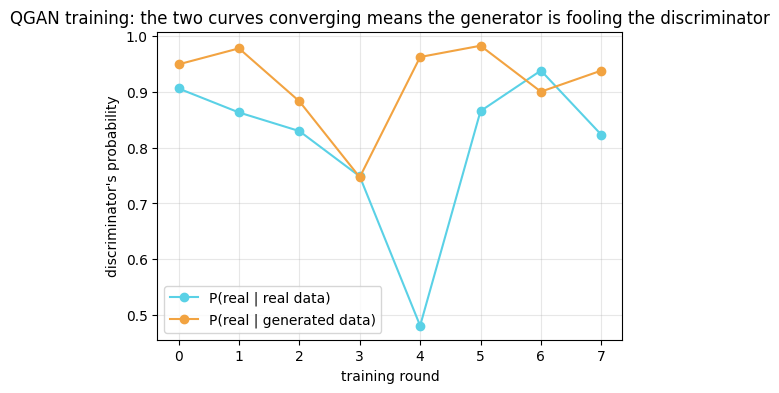

In [10]:
rounds, prs, pfs = zip(*gan_history)
plt.figure(figsize=(6, 4))
plt.plot(rounds, prs, "o-", label="P(real | real data)", color="#5ad1e6")
plt.plot(rounds, pfs, "o-", label="P(real | generated data)", color="#f2a341")
plt.xlabel("training round")
plt.ylabel("discriminator's probability")
plt.title("QGAN training: the two curves converging means the generator is fooling the discriminator")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 6. Did the Generator Actually Learn the Real Distribution?

Fooling the discriminator isn't automatically the same as truly matching the real data. Let's check directly by comparing each circuit's **Bloch vector** — the real, physical fingerprint of a single-qubit state (Module 5, Chapter 6).

In [11]:
dev1 = qml.device("default.qubit", wires=1)

@qml.qnode(dev1)
def real_stats(angles):
    qml.Rot(*angles, wires=0)
    return qml.expval(qml.PauliX(0)), qml.expval(qml.PauliY(0)), qml.expval(qml.PauliZ(0))

@qml.qnode(dev1)
def gen_stats(w):
    qml.RY(w[0], wires=0)
    qml.RX(w[1], wires=0)
    qml.RY(w[2], wires=0)
    return qml.expval(qml.PauliX(0)), qml.expval(qml.PauliY(0)), qml.expval(qml.PauliZ(0))

real_vec = np.array(real_stats(real_angles))
gen_vec = np.array(gen_stats(gen_weights))
print("Real Bloch vector:      ", real_vec.round(3))
print("Generated Bloch vector: ", gen_vec.round(3))
print("Euclidean distance between them:", np.linalg.norm(real_vec - gen_vec).round(3))

Real Bloch vector:       [0.433 0.75  0.5  ]
Generated Bloch vector:  [ 0.746  0.515 -0.422]
Euclidean distance between them: 1.001


**This is the honest, important lesson of this section:** the discriminator was successfully fooled (both probability curves converged), yet the generator's Bloch vector is only an approximate match to the real one, not a perfect one. This is a well-known, genuine characteristic of adversarial training — classical or quantum — and not a bug in the code above: a discriminator that's been fully fooled has, by definition, stopped providing a useful training signal, so the generator can stop improving before it's found a perfect match. Longer training, a better-balanced discriminator, or an entirely different loss (e.g. directly matching measurement statistics) are the usual fixes researchers reach for.

## 7. Recap & What's Next

| Concept | What you built |
|---|---|
| QCNN convolution | Shared 2-qubit trainable block applied to every neighboring pair |
| QCNN pooling | `CRZ`-based information hand-off, shrinking active qubits 8→4→2→1 |
| QCNN training | Full supervised training loop, reaching strong test accuracy on local-pattern data |
| Quantum generator | A trainable circuit producing a single-qubit state from scratch |
| Quantum discriminator | An entangling block scoring "how real" a state looks |
| Adversarial training | Alternating discriminator/generator updates — and an honest look at why it's unstable |

**Next notebook: `06_noise_error_mitigation.ipynb`** — Module 11, Part 2. Every circuit in this notebook ran on a perfect, noiseless simulator. Real quantum hardware isn't perfect — you'll add realistic noise and learn the basic techniques used to mitigate it.
